# Fase 1: Preparación y ETL de Datos (Parte 1) por Carlos Enrique Aguilar Maza

Este notebook lee dos archivos CSV, los limpia y los une utilizando Spark. Al final genera el archivo `nobel_consolidado.csv`.

## 1. Instalación e importación de PySpark

Esta celda está pensada para ejecutarse directamente en Google Colab.

In [3]:
!pip install -q pyspark

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, trim
import glob
import os
import shutil

In [4]:
spark = SparkSession.builder.appName('ETL Nobel').getOrCreate()

## 2. Lectura de los archivos CSV
Nota: por un metodo tradicional pyspark no puede leer direcatmente urls con formato HTML, dando el siguiente error UnsupportedOperationException: [FAILED_READ_FILE.UNSUPPORTED_FILE_SYSTEM] Encountered error while reading file https://raw.githubusercontent.com/anaepm/rep/refs/heads/main/nobel_personal.csv. The file system org.apache.hadoop.fs.http.HttpsFileSystem hasn't implemented listStatus. SQLSTATE: KD001 por lo tanto se opto por una alternativa usando Pandas.

In [5]:
import pandas as pd

# URLs de los datasets
url_personal = 'https://raw.githubusercontent.com/anaepm/rep/refs/heads/main/nobel_personal.csv'
url_data = 'https://raw.githubusercontent.com/anaepm/rep/refs/heads/main/nobel_data.csv'

# 1. Cargar datos desde la web con Pandas
personal_pd = pd.read_csv(url_personal)
data_pd = pd.read_csv(url_data)

# 2. Convertir a DataFrames de PySpark
personal = spark.createDataFrame(personal_pd)
data = spark.createDataFrame(data_pd)

# 3. Mostrar los resultados
print('Archivo personal:')
personal.show(5)

print('Archivo data:')
data.show(5)

Archivo personal:
+-----------+--------------+-----------+------+----------+--------------------+--------------------+------------------+----------+-------------+----------+------------------+------------------+-----------------+--------------------+
|Laureate_Id|     Firstname|   Lastname|Gender|Birth_Date|       Birth_Country|          Birth_City|Birth_Country_Code|Death_Date|Death_Country|Death_City|Death_Country_Code| Organization_Name|Organization_City|Organization_Country|
+-----------+--------------+-----------+------+----------+--------------------+--------------------+------------------+----------+-------------+----------+------------------+------------------+-----------------+--------------------+
|          1|Wilhelm Conrad|    Röntgen|  male|1845-03-27|Prussia (now Germ...|Lennep (now Remsc...|                DE|10/02/1923|      Germany|    Munich|                DE| Munich University|           Munich|             Germany|
|        293|          Emil|von Behring|  male|185

## 3. Limpieza de datos

Se quitan espacios de las columnas de texto, se eliminan filas repetidas y se descartan registros sin nombre o apellido, porque esas columnas son necesarias para realizar el join.

In [6]:
def limpiar_nombres(df):
    return (df
            .withColumn('Firstname', trim(col('Firstname')))
            .withColumn('Lastname', trim(col('Lastname')))
            .dropDuplicates()
            .dropna(subset=['Firstname', 'Lastname']))

personal = limpiar_nombres(personal)
data = limpiar_nombres(data)

## 4. Unión de los DataFrames

In [7]:
nobel_consolidado = personal.join(
    data,
    on=['Firstname', 'Lastname'],
    how='inner'
)

nobel_consolidado.show(5)
print('Total de registros:', nobel_consolidado.count())

+---------+--------+-----------+------+----------+--------------------+--------------------+------------------+----------+-------------+------------+------------------+--------------------+-----------------+--------------------+----+-----------+----------+-----------+--------------------+
|Firstname|Lastname|Laureate_Id|Gender|Birth_Date|       Birth_Country|          Birth_City|Birth_Country_Code|Death_Date|Death_Country|  Death_City|Death_Country_Code|   Organization_Name|Organization_City|Organization_Country|Year|Laureate_Id|  Category|Prize_Share|          Motivation|
+---------+--------+-----------+------+----------+--------------------+--------------------+------------------+----------+-------------+------------+------------------+--------------------+-----------------+--------------------+----+-----------+----------+-----------+--------------------+
| Ernst B.|   Chain|        340|  male|19/06/1906|             Germany|              Berlin|                DE|12/08/1979|      Ir

## 5. Exportación a `nobel_consolidado.csv`

Spark normalmente escribe una carpeta con varios archivos. Para entregar un solo CSV, se usa `coalesce(1)` y se cambia el nombre del archivo generado.

In [8]:
carpeta_salida = 'salida_nobel'

(nobel_consolidado.coalesce(1)
    .write
    .mode('overwrite')
    .option('header', True)
    .csv(carpeta_salida))

archivo_generado = glob.glob(os.path.join(carpeta_salida, 'part-*.csv'))[0]
shutil.move(archivo_generado, 'nobel_consolidado.csv')
shutil.rmtree(carpeta_salida)

print('Archivo creado: nobel_consolidado.csv')

Archivo creado: nobel_consolidado.csv


In [9]:
spark.stop()

# Fase 2: NLP, Modelado Predictivo y Streamlit

Continuación de la Fase 1 usando el archivo nobel_consolidado.csv

In [10]:
!pip install -q pandas nltk scikit-learn matplotlib wordcloud joblib streamlit

import re
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from wordcloud import WordCloud
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Sección 2: Procesamiento de lenguaje natural

In [11]:
#Leemos el cv
df = pd.read_csv('nobel_consolidado.csv')
df.head()


,Firstname,Lastname,Laureate_Id,Gender,Birth_Date,Birth_Country,Birth_City,Birth_Country_Code,Death_Date,Death_Country,Death_City,Death_Country_Code,Organization_Name,Organization_City,Organization_Country,Year,Laureate_Id.1,Category,Prize_Share,Motivation
0,Ernst B.,Chain,340.0,male,19/06/1906,Germany,Berlin,DE,12/08/1979,Ireland,Mulrany,IE,University of Oxford,Oxford,United Kingdom,1945.0,340.0,medicine,3.0,\for the discovery of penicillin and its curat...
1,Philip S.,Hench,351.0,male,1896-02-28,USA,Pittsburgh PA,US,30/03/1965,Jamaica,Ocho Rios,JM,Mayo Clinic,Rochester MN,USA,1950.0,351.0,medicine,3.0,\for their discoveries relating to the hormone...
2,Gerty,Cori,344.0,female,1896-08-15,Austria-Hungary (now Czech Republic),Prague,CZ,26/10/1957,USA,St. Louis MO,US,Washington University,St. Louis MO,USA,1947.0,344.0,medicine,4.0,\for their discovery of the course of the cata...
3,Fritz,Pregl,181.0,male,1869-09-03,Austria-Hungary (now Slovenia),Laibach (now Ljubljana),SI,13/12/1930,Austria,Graz,AT,Graz University,Graz,Austria,1923.0,181.0,chemistry,1.0,\for his invention of the method of micro-anal...
4,Jean-Paul,Sartre,637.0,male,21/06/1905,France,Paris,FR,15/04/1980,France,Paris,FR,NaN,NaN,NaN,1964.0,637.0,literature,1.0,\for his work which rich in ideas and filled w...


In [12]:
stop_words = set(stopwords.words('english'))

def limpiar_motivacion(texto):
    if pd.isna(texto):
        return ''
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto)
    palabras = texto.split()
    palabras = [palabra for palabra in palabras if palabra not in stop_words]
    return ' '.join(palabras)

df['Motivation_Clean'] = df['Motivation'].apply(limpiar_motivacion)
df[['Motivation', 'Motivation_Clean']].head()


,Motivation,Motivation_Clean
0,\for the discovery of penicillin and its curat...,discovery penicillin curative effect various i...
1,\for their discoveries relating to the hormone...,discoveries relating hormones adrenal cortex s...
2,\for their discovery of the course of the cata...,discovery course catalytic conversion glycogen
3,\for his invention of the method of micro-anal...,invention method micro analysis organic substa...
4,\for his work which rich in ideas and filled w...,work rich ideas filled spirit freedom quest tr...


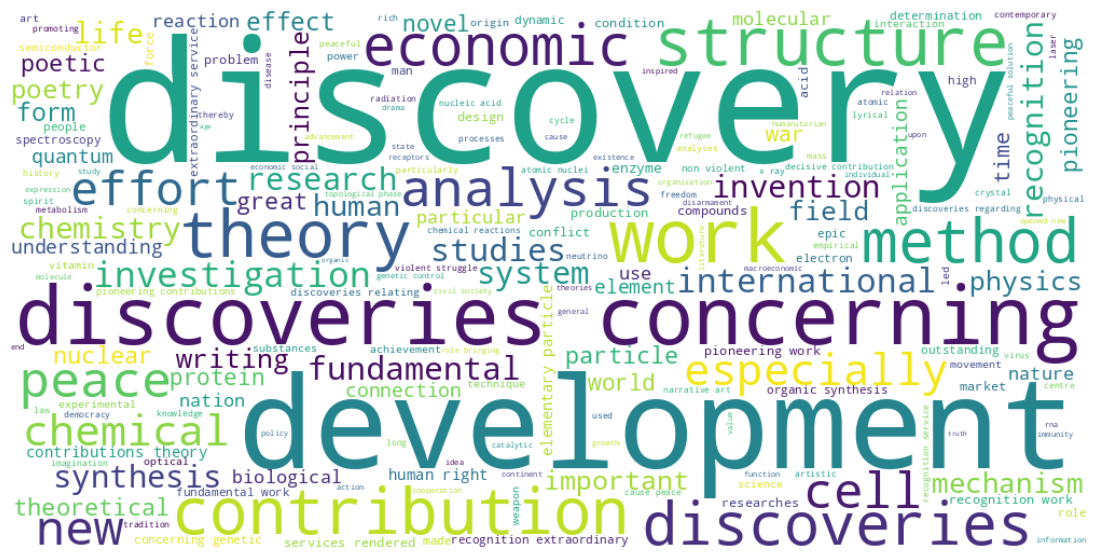

In [13]:
texto_completo = ' '.join(df['Motivation_Clean'])

nube = WordCloud(width=1000, height=500, background_color='white').generate(texto_completo)
plt.figure(figsize=(14, 7))
plt.imshow(nube, interpolation='bilinear')
plt.axis('off')
plt.show()


Sección 3: Modelado predictivo y evaluación

In [14]:
df_modelo = df.dropna(subset=['Motivation_Clean', 'Category']).copy()
df_modelo = df_modelo[df_modelo['Motivation_Clean'].str.strip() != '']

X = df_modelo['Motivation_Clean']
y = df_modelo['Category']

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

   chemistry       1.00      0.86      0.92        42
   economics       1.00      0.92      0.96        13
  literature       0.96      0.92      0.94        25
    medicine       0.89      0.95      0.92        44
       peace       1.00      0.93      0.96        28
     physics       0.85      0.98      0.91        47

    accuracy                           0.93       199
   macro avg       0.95      0.93      0.94       199
weighted avg       0.94      0.93      0.93       199



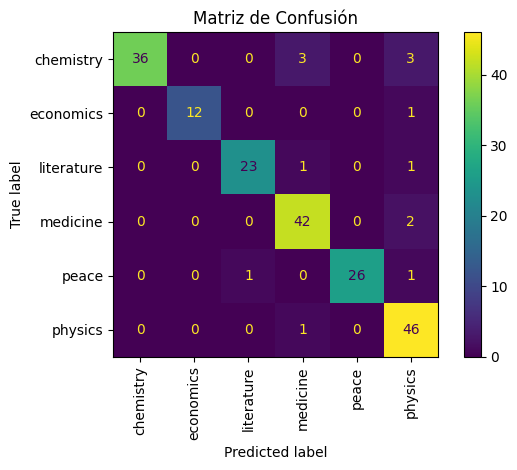

Se guardaron vectorizer.pkl y model.pkl


In [16]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation='vertical')
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

joblib.dump(vectorizer, 'vectorizer.pkl')
joblib.dump(model, 'model.pkl')
print('Se guardaron vectorizer.pkl y model.pkl')


# Sección 4: Aplicación interactiva en Streamlit

La siguiente celda crea el archivo app.py. Para ejecutarlo en Colab se puede usar !streamlit run app.py en un entorno con acceso a la aplicación.

In [17]:
%%writefile app.py
import re
import joblib
import nltk
import streamlit as st
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))
vectorizer = joblib.load('vectorizer.pkl')
model = joblib.load('model.pkl')

def limpiar_motivacion(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto)
    palabras = texto.split()
    palabras = [palabra for palabra in palabras if palabra not in stop_words]
    return ' '.join(palabras)

st.title('Predicción de Categoría Premio Nobel')
motivacion = st.text_area('Ingresa la motivación:')

if st.button('Predecir'):
    texto_limpio = limpiar_motivacion(motivacion)
    texto_transformado = vectorizer.transform([texto_limpio])
    prediccion = model.predict(texto_transformado)[0]
    st.success(f'Categoría estimada: {prediccion}')

Writing app.py


Predicciones para Test.csv

In [19]:
test = pd.read_csv('Test.csv')
test['Motivation_Clean'] = test['Motivation'].apply(limpiar_motivacion)
test_tfidf = vectorizer.transform(test['Motivation_Clean'])
test['Category_Predicted'] = model.predict(test_tfidf)

print(test[['Motivation', 'Category_Predicted']].to_string(index=False))

                                                                                                                                        Motivation Category_Predicted
                     For pioneering theoretical contributions and experimental observation of macroscopic quantum phenomena in topological matter.            physics
For tireless efforts to expose human rights violations, document war crimes and empower civil society organizations for democratic accountability.              peace
                     For discoveries concerning molecular mechanisms controlling circadian rhythms and cellular adaptation to oxygen availability.           medicine
                    For extraordinary contributions to international nuclear disarmament and establishing verifiable treaties for global security.            physics
                  For methodological contributions to the analysis of causal relationships in macroeconomic policy and labor market interventions.          economics
    

In [20]:
!curl https://loca.lt/mytempip

{"id":"mytempip","port":33093,"max_conn_count":2,"url":"https://mytempip.loca.lt"}

In [23]:
!streamlit run app.py & npx localtunnel --port 8501 --subdomain mi-app-nobel-123

⠙⠹⠸⠼⠴⠦

⠧⠇⠏⠋Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-09-20 17:47:19.138 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://8.228.18.147:8501

  Stopping...
^C
